# Clusterização com UMAP dos Padrões de Transição por Aluno


Este notebook lê as matrizes `.npz` por usuário (com eixos globais fixos), reduz a dimensionalidade com **UMAP** e realiza **clusterização** com **K-Means**.

**Pipeline:**
1. Carrega `axes_global.json` e `per_user_fixed_summary.csv` de `/mnt/data/markov_user_fixed_plots/`.
2. Lê `user_<ID>_order{1|2}.npz`, flatten de `P` (probabilidades).
3. Padroniza (StandardScaler) e projeta para 2D com **UMAP**.
4. Escolhe **K** via Elbow e avalia **silhouette** (K-Means).
5. Plota os pontos em 2D (UMAP) coloridos por cluster e salva **heatmaps médios por cluster**.

> Para usar 2ª ordem, mude `ORDER = 2` na célula de parâmetros.


In [1]:

# ============================================================
# 1) Imports e caminhos
# ============================================================
import os, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from umap import UMAP

BASE_DIR = "artifacts"

with open(os.path.join(BASE_DIR, "axes_global.json"), "r") as f:
    AXES = json.load(f)

STATES = AXES["states_global"]
SUPERSTATES = [tuple(x) for x in AXES["superstates_global"]]

summary_path = os.path.join(BASE_DIR, "per_user_fixed_summary.csv")
if not os.path.exists(summary_path):
    raise FileNotFoundError(f"Arquivo não encontrado: {summary_path}. Execute o notebook de salvamento NPZ antes.")
SUMMARY = pd.read_csv(summary_path)

print("n_states:", len(STATES), "| n_superstates:", len(SUPERSTATES), "| n_users:", len(SUMMARY))


/opt/homebrew/Caskroom/miniconda/base/envs/studychat/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


n_states: 32 | n_superstates: 722 | n_users: 201


In [2]:

# ============================================================
# 2) Parâmetros
# ============================================================
ORDER = 2          # 1 = 1ª ordem (|S|x|S|), 2 = 2ª ordem (|SuperS|x|S|)
MIN_EDGES = 0      # filtro mínimo de transições por usuário (0 = todos)

# UMAP
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
UMAP_N_COMPONENTS = 2
UMAP_METRIC = "cosine"
RANDOM_STATE = 42

# K-Means (método do cotovelo)
K_MIN, K_MAX = 2, 30

In [3]:

# ============================================================
# 3) Carregar vetores flatten por usuário
# ============================================================
def load_user_vector(uid: str, order: int):
    npz_path = os.path.join(BASE_DIR, f"user_{uid}_order{order}.npz")
    if not os.path.exists(npz_path):
        return None
    data = np.load(npz_path, allow_pickle=True)
    P = data["P"]  # matriz de probabilidades
    return P.flatten(), P.shape

vectors, user_ids = [], []
for _, row in SUMMARY.iterrows():
    uid = row["userId"]
    edges_col = "order1_edges" if ORDER == 1 else "order2_edges"
    if edges_col in row and row[edges_col] < MIN_EDGES:
        continue
    res = load_user_vector(uid, ORDER)
    if res is None:
        continue
    vec, shape = res
    vectors.append(vec)
    user_ids.append(uid)

if not vectors:
    raise RuntimeError("Nenhum vetor carregado. Confira se os .npz existem e se ORDER está correto.")

X = np.vstack(vectors)
print("Shape X:", X.shape, "| matriz base shape:", shape)


Shape X: (201, 23104) | matriz base shape: (722, 32)


/opt/homebrew/Caskroom/miniconda/base/envs/studychat/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


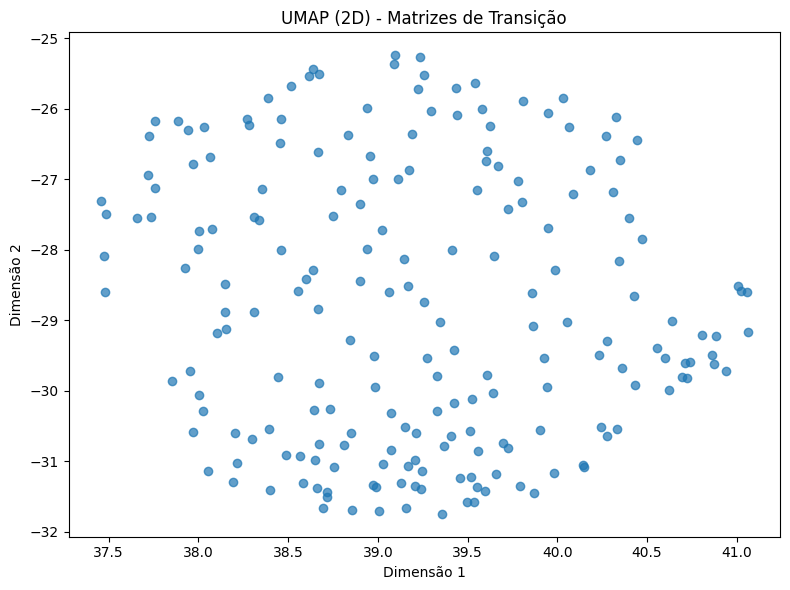

In [4]:

# ============================================================
# 4) Padronização e UMAP (visualização 2D)
# ============================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

umap = UMAP(
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    n_components=UMAP_N_COMPONENTS,
    metric=UMAP_METRIC,
    random_state=RANDOM_STATE
)
X_umap = umap.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_umap[:,0], X_umap[:,1], alpha=0.7)
plt.title("UMAP (2D) - Matrizes de Transição")
plt.xlabel("Dimensão 1"); plt.ylabel("Dimensão 2")
plt.tight_layout()
plt.show()


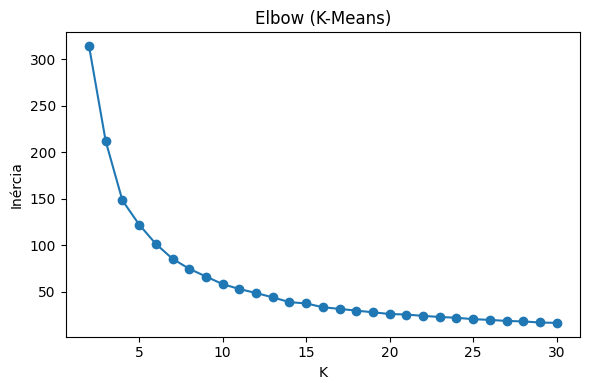

In [5]:

# ============================================================
# 5) Elbow (K-Means em X_scaled)
# ============================================================
inertias = []
KRANGE = list(range(K_MIN, K_MAX+1))
for k in KRANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_umap)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(KRANGE, inertias, '-o')
plt.title("Elbow (K-Means)")
plt.xlabel("K"); plt.ylabel("Inércia")
plt.tight_layout()
plt.show()


In [6]:
from kneed import KneeLocator

k_values = range(2, 31)
print(len(k_values), len(inertias))
kl = KneeLocator(k_values, inertias, curve="convex", direction="decreasing")
print("Knee encontrado em:", kl.elbow)
K_SELECTED = kl.elbow

29 29
Knee encontrado em: 8


In [7]:

# ============================================================
# 6) K-Means com K_SELECTED + Silhouette
# ============================================================
kmeans = KMeans(n_clusters=K_SELECTED, random_state=RANDOM_STATE, n_init=10)
labels = kmeans.fit_predict(X_umap)

sil = silhouette_score(X_umap, labels)
print(f"Silhouette (K={K_SELECTED}): {sil:.3f}")

clusters_df = pd.DataFrame({"userId": user_ids, "cluster": labels})
out_csv = os.path.join(BASE_DIR, f"user_cluster_labels_umap_order{ORDER}.csv")
clusters_df.to_csv(out_csv, index=False, encoding="utf-8")
print("Salvo:", out_csv)
clusters_df.head()


Silhouette (K=8): 0.367
Salvo: artifacts/user_cluster_labels_umap_order2.csv


,userId,cluster
0,117bf560-5011-70e9-de01-b833f5651c83,0
1,f16b2520-6021-70ee-b980-7a50d804795d,0
2,81fbe5c0-8001-7054-3ac3-3e9db3f6e198,0
3,e12ba500-f0e1-70f2-73ab-05c1cbc44b76,7
4,b19b0560-c011-70d1-0a4f-c32cfa1ae4cd,7


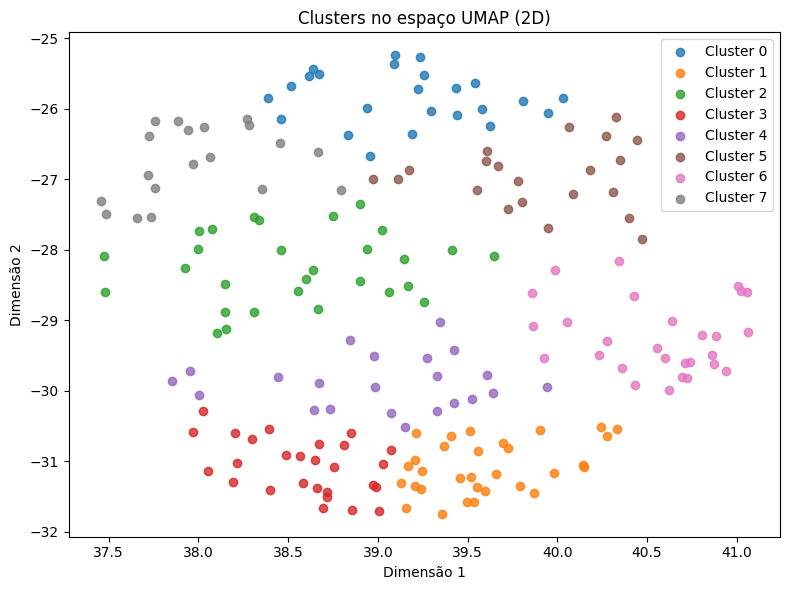

In [8]:

# ============================================================
# 7) Visualização de clusters no espaço UMAP
# ============================================================
plt.figure(figsize=(8,6))
for c in sorted(set(labels)):
    pts = X_umap[labels == c]
    plt.scatter(pts[:,0], pts[:,1], alpha=0.8, label=f"Cluster {c}")
plt.legend()
plt.title("Clusters no espaço UMAP (2D)")
plt.xlabel("Dimensão 1"); plt.ylabel("Dimensão 2")
plt.tight_layout()
plt.show()


In [9]:

# ============================================================
# 8) Heatmaps médios por cluster + global
# ============================================================
n_rows, n_cols = shape
row_labels = STATES if ORDER == 1 else [f"{a}|{b}" for (a,b) in SUPERSTATES]
col_labels = STATES

# Médias por cluster
for c in sorted(set(labels)):
    member_idx = np.where(labels == c)[0]
    mean_vec = X[member_idx].mean(axis=0)
    M_mean = mean_vec.reshape(n_rows, n_cols)

    plt.figure(figsize=(10, 8))
    plt.imshow(M_mean, aspect='auto', vmin=0, vmax=1)
    plt.title(f"Matriz média do Cluster {c} (order {ORDER})")
    plt.xlabel("Próximo estado")
    plt.ylabel("Estado atual" if ORDER == 1 else "Par de estados (histórico)")
    plt.xticks(range(len(col_labels)), col_labels, rotation=90)
    if len(row_labels) > 40:
        step = max(1, len(row_labels)//40)
        idxs = list(range(0, len(row_labels), step))
        ylabs = [row_labels[i] for i in idxs]
        plt.yticks(idxs, ylabs)
    else:
        plt.yticks(range(len(row_labels)), row_labels)
    plt.colorbar()
    plt.tight_layout()
    out_png = os.path.join(BASE_DIR, f"cluster_{c}_mean_heatmap_umap_order{ORDER}.png")
    plt.savefig(out_png, dpi=160)
    plt.close()
    print("Salvo:", out_png)

# Heatmap GLOBAL (todos os usuários)
M_global = X.mean(axis=0).reshape(n_rows, n_cols)
plt.figure(figsize=(10, 8))
plt.imshow(M_global, aspect='auto', vmin=0, vmax=1)
plt.title(f"Matriz média GLOBAL (order {ORDER})")
plt.xlabel("Próximo estado")
plt.ylabel("Estado atual" if ORDER == 1 else "Par de estados (histórico)")
plt.xticks(range(len(col_labels)), col_labels, rotation=90)
if len(row_labels) > 40:
    step = max(1, len(row_labels)//40)
    idxs = list(range(0, len(row_labels), step))
    ylabs = [row_labels[i] for i in idxs]
    plt.yticks(idxs, ylabs)
else:
    plt.yticks(range(len(row_labels)), row_labels)
plt.colorbar()
plt.tight_layout()
out_png = os.path.join(BASE_DIR, f"cluster_mean_heatmap_umap_order{ORDER}.png")
plt.savefig(out_png, dpi=160)
plt.close()
print("Salvo:", out_png)


Salvo: artifacts/cluster_0_mean_heatmap_umap_order2.png
Salvo: artifacts/cluster_1_mean_heatmap_umap_order2.png
Salvo: artifacts/cluster_2_mean_heatmap_umap_order2.png
Salvo: artifacts/cluster_3_mean_heatmap_umap_order2.png
Salvo: artifacts/cluster_4_mean_heatmap_umap_order2.png
Salvo: artifacts/cluster_5_mean_heatmap_umap_order2.png
Salvo: artifacts/cluster_6_mean_heatmap_umap_order2.png
Salvo: artifacts/cluster_7_mean_heatmap_umap_order2.png
Salvo: artifacts/cluster_mean_heatmap_umap_order2.png
